# scikit-learn Bootcamp — W2, Day 15
```
##### Logistic Regression — DX/RX Patient Conversion (Portfolio Arc Notebook 1/3)
##### This notebook upgrades the DX/RX model from SciPy W1D5 Q6 using sklearn.
##### regularization · Pipeline · calibration · business metrics · ROI framing
##### Q1 — EDA: DX/RX patient journey dataset (richer features than SciPy version)
##### Q2 — Baseline: replicate SciPy manual logistic vs sklearn LogisticRegression
##### Q3 — Regularization: L1/L2/ElasticNet — select best C via CV
##### Q4 — Calibration: are the probabilities trustworthy?
##### Q5 — Business framing: convert AUC to appointment revenue impact
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, brier_score_loss
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

In [40]:
# Dataset — DX/RX Patient Conversion (upgraded from SciPy W1D5)
np.random.seed(420)
n = 6000
age             = np.random.normal(47, 14, n).clip(18, 85).astype(int)
symptom_count   = np.random.poisson(2.8, n).clip(0, 12)
drug_searches   = np.random.poisson(1.5, n).clip(0, 10)
session_depth   = np.random.poisson(4.2, n).clip(1, 25)
time_on_site    = np.random.lognormal(1.8, 0.7, n).clip(0.5, 90)
is_mobile       = np.random.binomial(1, 0.55, n)
has_insurance   = np.random.binomial(1, 0.72, n)
prior_appts     = np.random.poisson(0.8, n).clip(0, 10)
dx_content_pct  = np.random.beta(2, 3, n)   # % time on diagnostic content

log_odds = (-3.0 + 0.018*age + 0.22*symptom_count + 0.18*drug_searches
            + 0.15*session_depth + 0.06*time_on_site
            + 1.2*dx_content_pct + 0.45*has_insurance + 0.35*prior_appts
            - 0.20*is_mobile + np.random.normal(0, 0.4, n))
booked = (1/(1+np.exp(-log_odds)) > np.random.rand(n)).astype(int)

df = pd.DataFrame({
    'age': age, 'symptom_count': symptom_count, 'drug_searches': drug_searches,
    'session_depth': session_depth, 'time_on_site': time_on_site.round(2),
    'is_mobile': is_mobile, 'has_insurance': has_insurance, 'prior_appts': prior_appts,
    'dx_content_pct': dx_content_pct.round(4), 'booked': booked
})
feat_cols = [c for c in df.columns if c != 'booked']
X = df[feat_cols]; y = df['booked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print('Shape:', df.shape, '| Booking rate:', y.mean().round(3))
display(df.head())

Shape: (6000, 10) | Booking rate: 0.658


,age,symptom_count,drug_searches,session_depth,time_on_site,is_mobile,has_insurance,prior_appts,dx_content_pct,booked
0,40,2,2,2,13.31,1,1,0,0.4681,1
1,20,8,1,5,5.23,0,1,0,0.6463,1
2,39,1,1,6,15.33,0,1,1,0.4633,0
3,42,6,0,5,10.35,1,0,1,0.2942,0
4,51,5,1,9,1.75,1,1,2,0.5102,1


---
### Q1 — EDA
```
# (a) Distribution of booking rate across key feature quartiles (3x3 grid).
# (b) Correlation heatmap. Which features predict booking most?
# (c) KDE: booked vs not-booked for top 4 predictors.
# (d) Insurance vs no insurance: booking rate comparison (bar chart + CI).
```

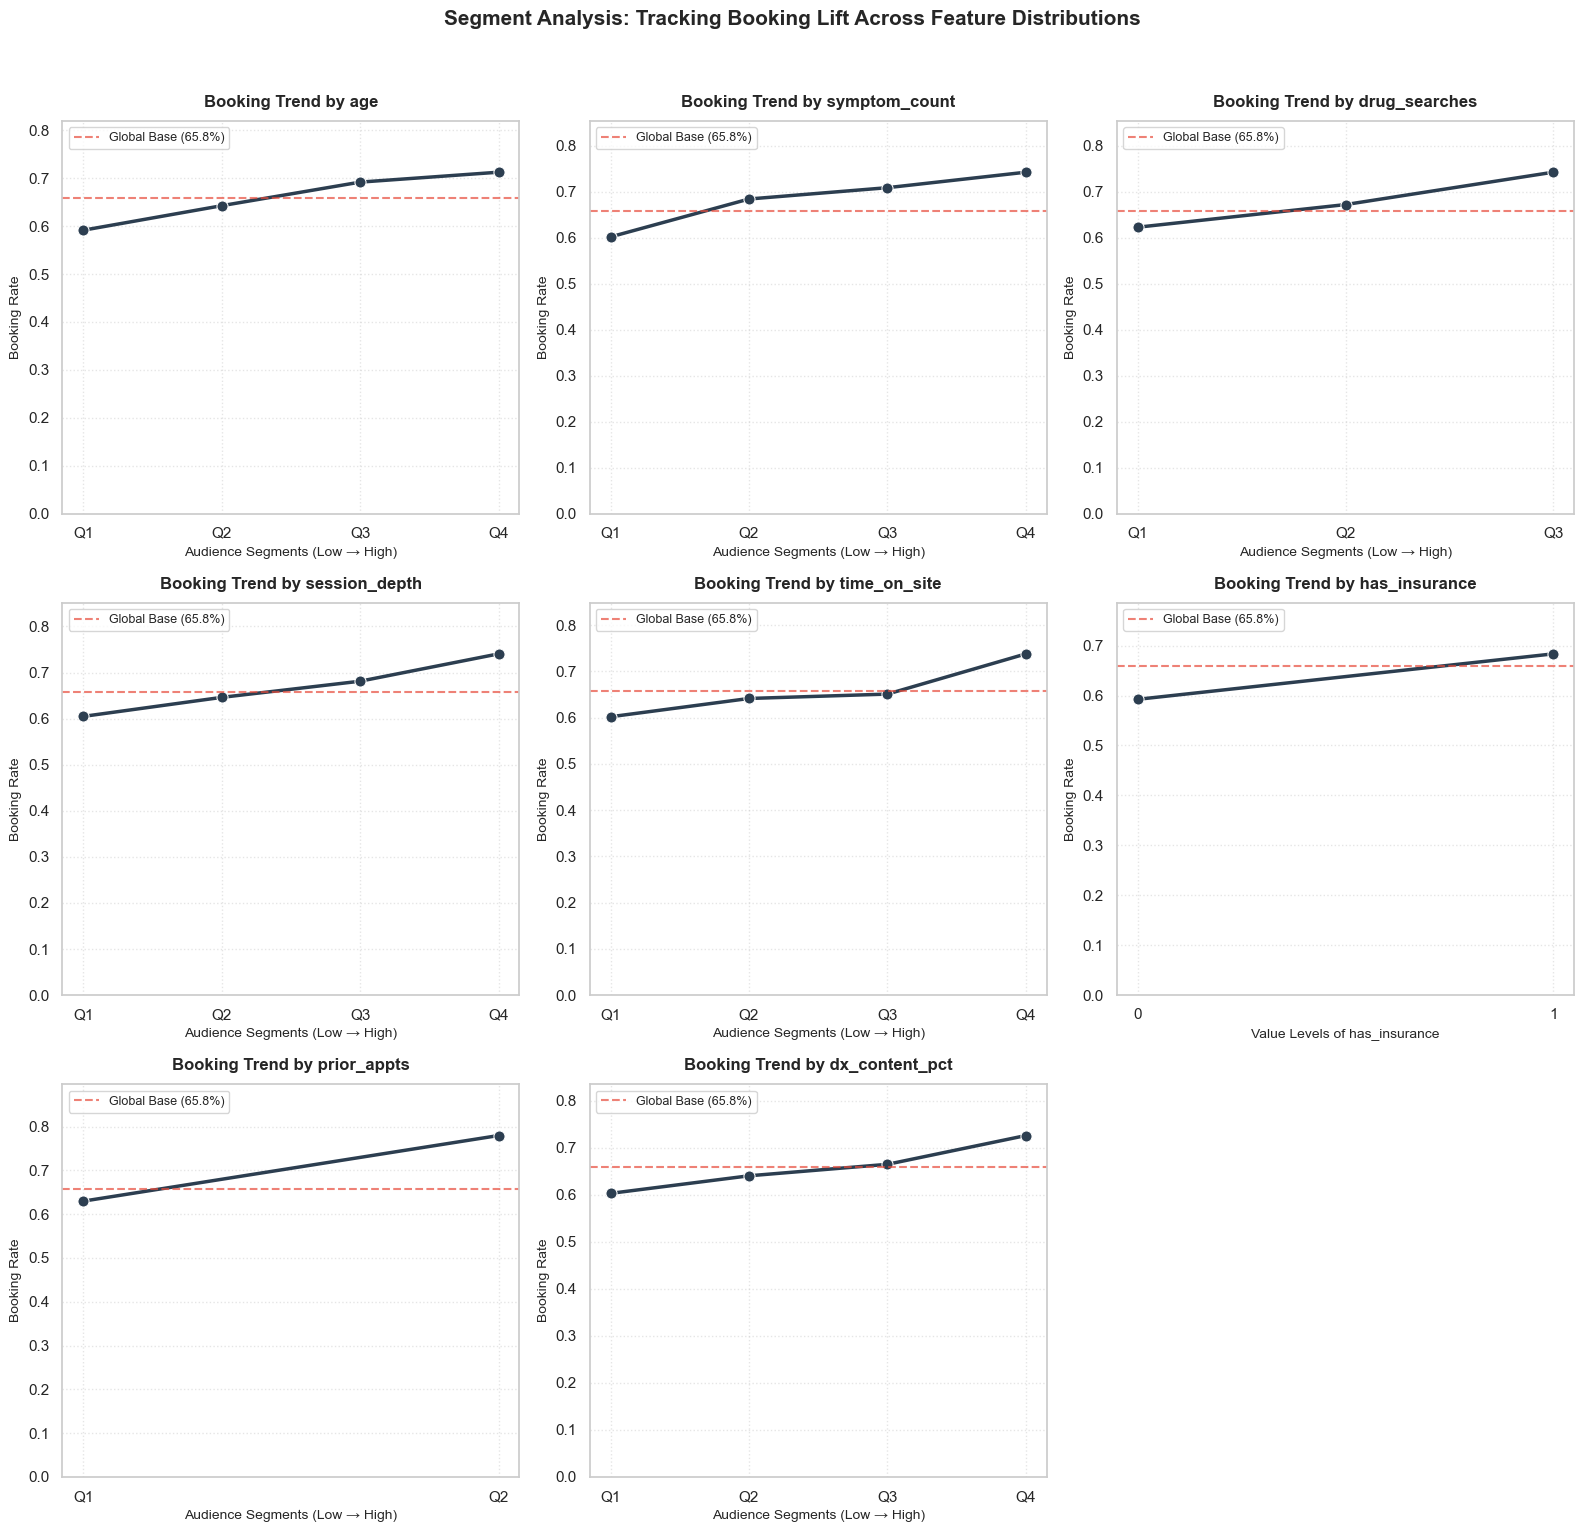

In [ ]:
# (a) Distribution of booking rate across key feature quartiles (3x3 grid).

# 1. Target features
segment_features = ['age', 'symptom_count', 'drug_searches', 'session_depth', 
                    'time_on_site', 'has_insurance', 'prior_appts', 'dx_content_pct']

# 2. Configure a clean 3x3 grid canvas
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()
global_book_rate = y.mean()

# 3. Loop through features
for i, col in enumerate(segment_features):
    unique_vals = df[col].nunique()
    
    # If a feature has very few unique values, group by value directly
    if unique_vals <= 5:
        segment_data = df.groupby(col, observed=False)['booked'].mean().reset_index()
        segment_data.columns = ['Segment', 'Booking Rate']
        segment_data['Segment'] = segment_data['Segment'].astype(str)
    else:
        # Compute the raw quantiles first to see how many unique edges we get
        quantiles = np.linspace(0, 1, 5) # 4 bins = 5 edges
        bin_edges = np.unique(df[col].quantile(quantiles))
        num_actual_bins = len(bin_edges) - 1
        
        if num_actual_bins < 2:
            # Fallback to equal-width bins if quantiles collapse completely
            df[f'{col}_bin'] = pd.cut(df[col], bins=4, labels=['B1', 'B2', 'B3', 'B4'])
        else:
            # Dynamically generate the exact number of required labels
            labels = [f'Q{k+1}' for k in range(num_actual_bins)]
            df[f'{col}_bin'] = pd.qcut(df[col], q=4, labels=labels, duplicates='drop')
            
        segment_data = df.groupby(f'{col}_bin', observed=False)['booked'].mean().reset_index()
        segment_data.columns = ['Segment', 'Booking Rate']

    # 4. Plotting
    sns.lineplot(
        data=segment_data, x='Segment', y='Booking Rate', 
        ax=axes[i], marker='o', linewidth=2.5, color='#2c3e50', markersize=8
    )
    
    axes[i].axhline(y=global_book_rate, color='#e74c3c', linestyle='--', alpha=0.7, 
                    label=f'Global Base ({global_book_rate:.1%})')
    
    # Titles and formatting polish
    axes[i].set_title(f'Booking Trend by {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Booking Rate', fontsize=10)
    axes[i].set_xlabel('Audience Segments (Low → High)' if unique_vals > 5 else f'Value Levels of {col}', fontsize=10)
    
    max_rate = segment_data['Booking Rate'].max()
    axes[i].set_ylim(0, min(1.0, max_rate * 1.15))
    
    axes[i].grid(True, linestyle=':', alpha=0.5)
    axes[i].legend(loc='upper left', frameon=True, fontsize=9)

# Clean up the unused 9th plot frame at index 8
fig.delaxes(axes[8])

plt.suptitle('Segment Analysis: Tracking Booking Lift Across Feature Distributions', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


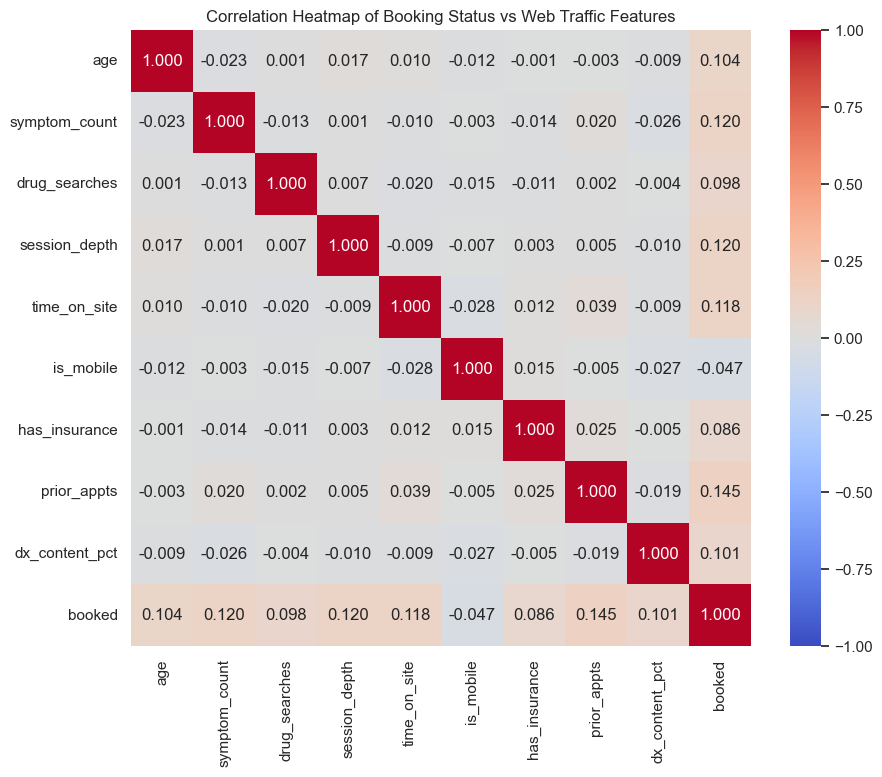


Linear Correlation with booking:
booked            1.000000
prior_appts       0.145122
symptom_count     0.120444
session_depth     0.120103
time_on_site      0.117998
age               0.103936
dx_content_pct    0.101331
drug_searches     0.097998
has_insurance     0.085917
is_mobile        -0.046580
Name: booked, dtype: float64


In [ ]:
# (b) Correlation heatmap. Which features predict booking most?

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Booking Status vs Web Traffic Features')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with booking:")
print(corr_matrix['booked'].sort_values(ascending=False))

# Top 4 features predict booking most: prior_appts, symptom_count, session_depths and time_on_site 

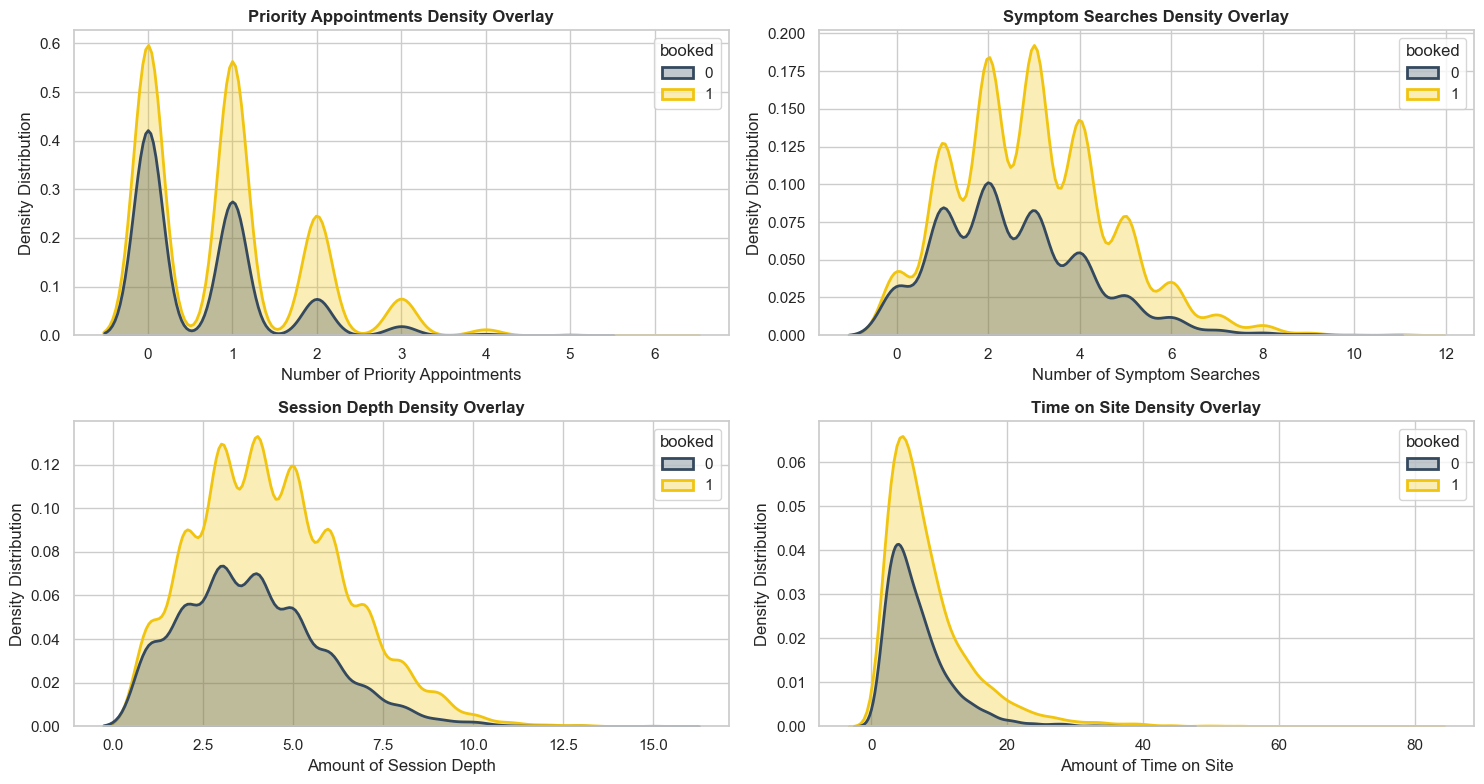

In [34]:
# (c) KDE: booked vs not-booked for top 4 predictors.

plt.figure(figsize=(15, 8))

# Subplot 1: Distribution overlay for prior_appts

plt.subplot(2, 2, 1)
sns.kdeplot(
    data=df,
    x='prior_appts',
    hue='booked',
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Priority Appointments Density Overlay', fontweight='bold')
plt.xlabel('Number of Priority Appointments')
plt.ylabel('Density Distribution')

# Subplot 2: Distribution overlay for symptom_count

plt.subplot(2, 2, 2)
sns.kdeplot(
    data=df,
    x='symptom_count',
    hue='booked',
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Symptom Searches Density Overlay', fontweight='bold')
plt.xlabel('Number of Symptom Searches')
plt.ylabel('Density Distribution')

# Subplot 3: Distribution overlay for session_depth

plt.subplot(2, 2, 3)
sns.kdeplot(
    data=df,
    x='session_depth',
    hue='booked',
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Session Depth Density Overlay', fontweight='bold')
plt.xlabel('Amount of Session Depth')
plt.ylabel('Density Distribution')


# Subplot 4: Distribution overlay for time_on_site

plt.subplot(2, 2, 4)
sns.kdeplot(
    data=df,
    x='time_on_site',
    hue='booked',
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Time on Site Density Overlay', fontweight='bold')
plt.xlabel('Amount of Time on Site')
plt.ylabel('Density Distribution')
plt.tight_layout()
plt.show()

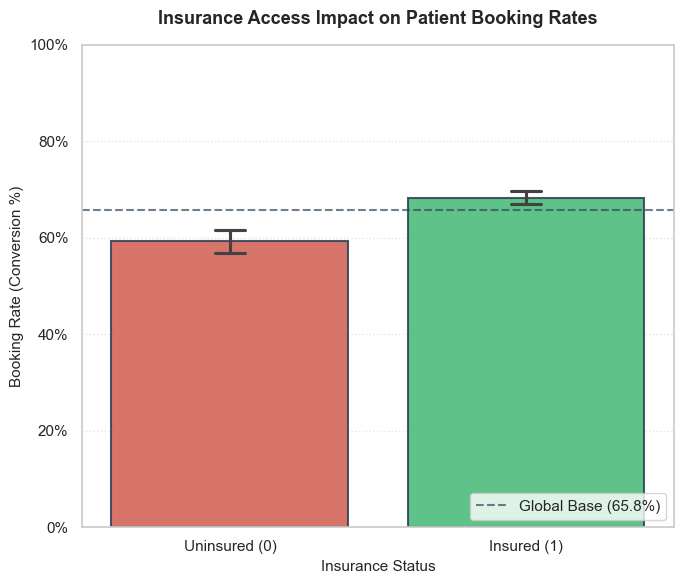

In [36]:
# (d) Insurance vs no insurance: booking rate comparison (bar chart + CI).

plt.figure(figsize=(7, 6))

# 1. Plot conversion rates across insurance status
sns.barplot(
    data=df, 
    x='has_insurance', 
    y='booked', 
    errorbar='ci',           # Adds standard 95% confidence intervals
    palette={'0': '#e74c3c', '1': '#2ecc71'}, # Red for uninsured, Green for insured
    alpha=0.85,
    capsize=0.1,             # Standard caps on the error bars
    edgecolor='#2c3e50',
    linewidth=1.5
)

# 2. Map binary labels to intuitive text
plt.xticks(ticks=[0, 1], labels=['Uninsured (0)', 'Insured (1)'], fontsize=11)

# 3. Reference line for the true baseline booking rate
global_book_rate = y.mean()
plt.axhline(
    y=global_book_rate, 
    color='#34495e', 
    linestyle='--', 
    alpha=0.7, 
    label=f'Global Base ({global_book_rate:.1%})'
)

# 4. Polish labels and limits
plt.title('Insurance Access Impact on Patient Booking Rates', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Insurance Status', fontsize=11)
plt.ylabel('Booking Rate (Conversion %)', fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) # format y-axis as %
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


---
### Q2 — Baseline: sklearn LogisticRegression
```
# (a) Fit LogisticRegression(C=1.0). Print AUC, classification report.
# (b) Plot coefficient bar chart. Which features drive booking most?
# (c) Compare to a dummy classifier (majority class baseline).
# (d) Plot ROC curve. Shade AUC.
```

In [44]:
# (a) Fit LogisticRegression(C=1.0). Print AUC, classification report.

lr = Pipeline([('scaler', StandardScaler()),
            ('model', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))
])

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]   # probability of positive class

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Booked', 'Booked']))

AUC-ROC: 0.6756

              precision    recall  f1-score   support

   No Booked       0.53      0.28      0.36       410
      Booked       0.70      0.87      0.78       790

    accuracy                           0.67      1200
   macro avg       0.61      0.58      0.57      1200
weighted avg       0.64      0.67      0.64      1200



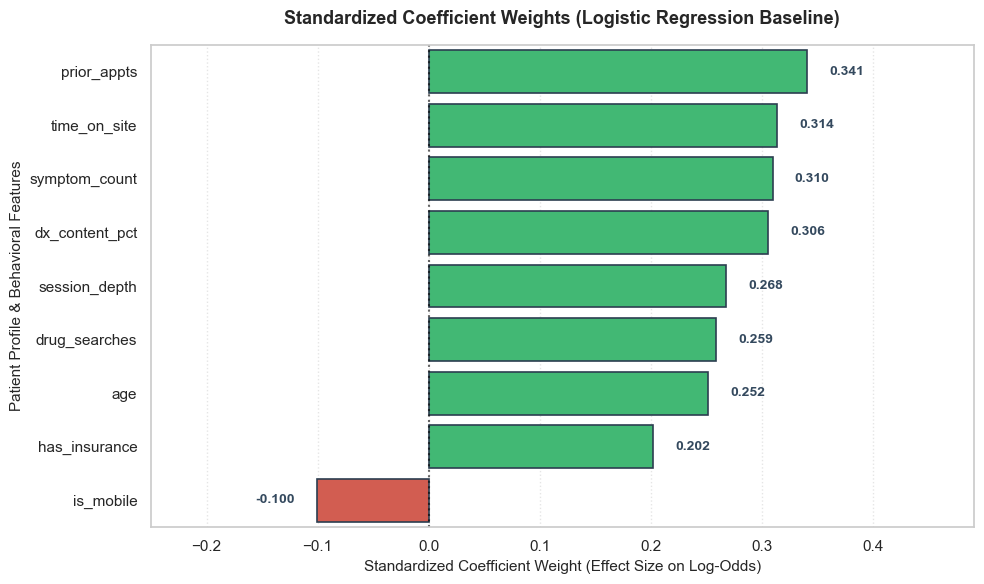

In [ ]:
# (b) Plot coefficient bar chart. 

# 1. Obtain the model from the pipeline step
log_model = lr.named_steps['model']

# 2. Extract and organize coefficients into a sorted DataFrame
df_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]  # Extracted from the 2D array
})

# Sort the features by impact BEFORE any reshaping for a perfect visual hierarchy
df_coefs = df_coefs.sort_values(by='Coefficient', ascending=False)

# 3. Create a clean, production-ready horizontal bar chart
plt.figure(figsize=(10, 6))

# Map colors dynamically: Green for positive drivers, Red for negative drivers
colors = ['#2ecc71' if c >= 0 else '#e74c3c' for c in df_coefs['Coefficient']]

sns.barplot(
    data=df_coefs, 
    x='Coefficient', 
    y='Feature', 
    palette=colors,
    edgecolor='#2c3e50',
    linewidth=1.2
)

# Add a vertical visual anchor line at zero
plt.axvline(0, color='black', linestyle=':', alpha=0.6, linewidth=1.5)

# 4. Polish labels, text annotations, and formatting
plt.title('Standardized Coefficient Weights (Logistic Regression Baseline)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Standardized Coefficient Weight (Effect Size on Log-Odds)', fontsize=11)
plt.ylabel('Patient Profile & Behavioral Features', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Add numeric value labels on the bars for extreme scannability
for index, row in enumerate(df_coefs.itertuples()):
    # Shift text slightly right for positive values, left for negative values
    ha_align = 'left' if row.Coefficient >= 0 else 'right'
    offset = 0.02 if row.Coefficient >= 0 else -0.02
    plt.text(
        row.Coefficient + offset, index, f'{row.Coefficient:.3f}', 
        va='center', ha=ha_align, fontsize=10, fontweight='bold', color='#34495e'
    )

# Leave clean breathing room for the text labels on the outer edges
plt.xlim(df_coefs['Coefficient'].min() - 0.15, df_coefs['Coefficient'].max() + 0.15)

plt.tight_layout()
plt.show()


```
# Which features drive booking most?

1/ Absolute Driver: prior_appts (+0.341). A standard deviation increase in a patient's historical appointment count provides the largest positive impact on their log-odds of booking.

2/ Grouping (The Behavior Cluster): time_on_site (+0.314), symptom_count (+0.310), and dx_content_pct (+0.306). These three sit in a near-identical tier, meaning active, research-heavy engagement strongly flags an impending booking.

3/ The Only Inhibitor: is_mobile (-0.100). This is the lone negative force dragging down conversion probability.

In [52]:
# (c) Compare to a dummy classifier (majority class baseline).

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Instantiate and fit the majority class dummy baseline
# 'most_frequent' always predicts the class with the highest presence (Booked)
dummy = DummyClassifier(strategy='most_frequent', random_state=420)
dummy.fit(X_train, y_train)

# 2. Generate predictions and probability outputs
dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

# 3. Calculate baseline metrics
dummy_auc = roc_auc_score(y_test, dummy_prob)
dummy_acc = accuracy_score(y_test, dummy_pred)
lr_acc = accuracy_score(y_test, y_pred) # assuming y_pred is from your LR model

# 4. Print structured benchmark comparison
print("==================================================")
print("     BASELINE COMPARISON: LR VS. DUMMY MODEL")
print("==================================================")
print(f"Logistic Regression AUC: {auc:.4f}  | Accuracy: {lr_acc:.1%}")
print(f"Dummy Classifier    AUC: {dummy_auc:.4f}  | Accuracy: {dummy_acc:.1%}")
print("\n--- Dummy Classifier Performance Report ---")
print(classification_report(y_test, dummy_pred, target_names=['No Booked', 'Booked'], zero_division=0))


     BASELINE COMPARISON: LR VS. DUMMY MODEL
Logistic Regression AUC: 0.6756  | Accuracy: 66.9%
Dummy Classifier    AUC: 0.5000  | Accuracy: 65.8%

--- Dummy Classifier Performance Report ---
              precision    recall  f1-score   support

   No Booked       0.00      0.00      0.00       410
      Booked       0.66      1.00      0.79       790

    accuracy                           0.66      1200
   macro avg       0.33      0.50      0.40      1200
weighted avg       0.43      0.66      0.52      1200



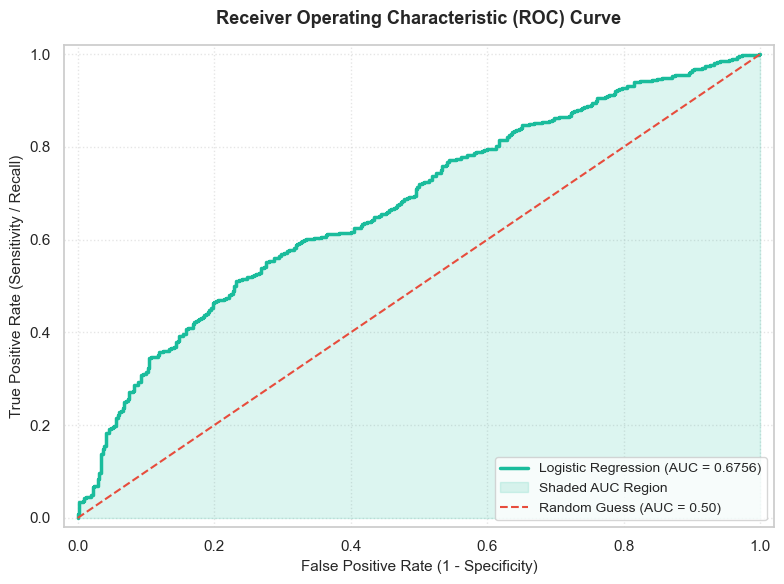

In [ ]:
# (d) Plot ROC curve. Shade AUC.

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Manually compute the curve coordinates from model probabilities
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# 2. Plot the main ROC trajectory line
plt.plot(fpr, tpr, color='#1abc9c', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')

# 3. CRUCIAL ADDITION: Shade the area beneath the ROC Curve
plt.fill_between(fpr, tpr, color='#1abc9c', alpha=0.15, label='Shaded AUC Region')

# 4. Draw the diagonal random baseline reference line
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

# 5. Visual presentation polish
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


---
### Q3 — Regularization: L1/L2/ElasticNet
```
# (a) GridSearchCV over C=[0.001,0.01,0.1,1,10,100] for L2.
#     Print best C and CV AUC.
# (b) Repeat for L1 (solver='saga') and ElasticNet.
# (c) Plot AUC vs log(C) for all 3 regularization types.
# (d) Compare feature sparsity: how many features zeroed by L1 at optimal C?
```

In [85]:
# (a) GridSearchCV over C=[[0.0001, 0.001,0.01,0.1,1,10,100] for L2.
#     Print best C and CV AUC.

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

# 1. Configure the Logistic Regression CV Pipeline

lr_ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        Cs=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  
        penalty='l2',                  # Explicitly enforces Ridge L2 regularization
        cv=5,                          # 5-fold Stratified Cross-Validation
        scoring='roc_auc',             # Tune hyperparameters to maximize AUC-ROC
        solver='lbfgs',
        max_iter=1000,
        random_state=420,
        n_jobs=-1                      # Use all CPU cores for faster tuning
    ))
])

# 2. Fit the Cross-Validated Pipeline
lr_ridge_cv.fit(X_train, y_train)

# 3. Extract the Optimal "Best" Hyperparameter found by CV
best_ridge = lr_ridge_cv.named_steps['model']
print(f"Optimal Ridge Penalty Strength Found (C): {best_ridge.C_[0]:.4f}")

# 4. Generate Predictions & Evaluate Performance
y_pred_cv = lr_ridge_cv.predict(X_test)
y_prob_cv = lr_ridge_cv.predict_proba(X_test)[:, 1]

print(f"CV Optimized AUC-ROC: {roc_auc_score(y_test, y_prob_cv):.4f}")
print("\n--- Ridge Optimized Classification Report ---")
print(classification_report(y_test, y_pred_cv, target_names=['No Booked', 'Booked']))

Optimal Ridge Penalty Strength Found (C): 10.0000
CV Optimized AUC-ROC: 0.6756

--- Ridge Optimized Classification Report ---
              precision    recall  f1-score   support

   No Booked       0.53      0.28      0.36       410
      Booked       0.70      0.87      0.78       790

    accuracy                           0.67      1200
   macro avg       0.61      0.58      0.57      1200
weighted avg       0.64      0.67      0.64      1200



In [86]:
# (b) Repeat for L1 (solver='saga') and ElasticNet.

# L1

# 1. Configure the Logistic Regression CV Pipeline
lr_lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        Cs=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  
        penalty='l1',                  # Explicitly enforces Ridge L1 regularization
        cv=5,                          # 5-fold Stratified Cross-Validation
        scoring='roc_auc',             # Tune hyperparameters to maximize AUC-ROC
        solver='saga',
        max_iter=5000,                 # Bumped up slightly because SAGA converges slower with L1
        random_state=420,
        n_jobs=-1                      # Use all CPU cores for faster tuning
    ))
])

# 2. Fit the Cross-Validated Pipeline
lr_lasso_cv.fit(X_train, y_train)

# 3. Extract the Optimal "Best" Hyperparameter found by CV
best_lasso = lr_lasso_cv.named_steps['model']
print(f"Optimal Lasso Penalty Strength Found (C): {best_lasso.C_[0]:.4f}")

# 4. Generate Predictions & Evaluate Performance
y_pred_cv = lr_lasso_cv.predict(X_test)
y_prob_cv = lr_lasso_cv.predict_proba(X_test)[:, 1]

print(f"L1 CV Optimized AUC-ROC: {roc_auc_score(y_test, y_prob_cv):.4f}")
print("\n--- L1 Optimized Classification Report ---")
print(classification_report(y_test, y_pred_cv, target_names=['No Booked', 'Booked']))

Optimal Lasso Penalty Strength Found (C): 100.0000
L1 CV Optimized AUC-ROC: 0.6756

--- L1 Optimized Classification Report ---
              precision    recall  f1-score   support

   No Booked       0.53      0.28      0.36       410
      Booked       0.70      0.87      0.78       790

    accuracy                           0.67      1200
   macro avg       0.61      0.58      0.57      1200
weighted avg       0.64      0.67      0.64      1200



In [88]:
# Elastic Net

# 1. Configure the Logistic Regression CV Pipeline
lr_elastic_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        Cs=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  
        penalty='elasticnet',            # Enforces blended L1/L2
        l1_ratios=[0.2, 0.5, 0.8],       # CRUCIAL: Grid search ratios (0=Pure Ridge, 1=Pure Lasso)
        cv=5,                          
        scoring='roc_auc',             
        solver='saga',                   # SAGA is required for ElasticNet
        max_iter=5000,                   
        random_state=420,
        n_jobs=-1                      
    ))
])

# 2. Fit the Cross-Validated Pipeline
lr_elastic_cv.fit(X_train, y_train)

# 3. Extract the Optimal "Best" Hyperparameter found by CV
best_elastic = lr_elastic_cv.named_steps['model']
print(f"Optimal ElasticNet Strength (C): {best_elastic.C_[0]:.4f}")

# Generate Predictions & Evaluate Performance
y_pred_cv = lr_elastic_cv.predict(X_test)
y_prob_cv = lr_elastic_cv.predict_proba(X_test)[:, 1]

print(f"Optimal L1 Blend Ratio (l1_ratio): {best_elastic.l1_ratio_[0]:.4f}")
print(f"ElasticNet Test AUC-ROC: {roc_auc_score(y_test, y_prob_cv):.4f}")
print("\n--- Elastic Net Optimized Classification Report ---")
print(classification_report(y_test, y_pred_cv, target_names=['No Booked', 'Booked']))

Optimal ElasticNet Strength (C): 100.0000
Optimal L1 Blend Ratio (l1_ratio): 0.8000
ElasticNet Test AUC-ROC: 0.6756

--- Elastic Net Optimized Classification Report ---
              precision    recall  f1-score   support

   No Booked       0.53      0.28      0.36       410
      Booked       0.70      0.87      0.78       790

    accuracy                           0.67      1200
   macro avg       0.61      0.58      0.57      1200
weighted avg       0.64      0.67      0.64      1200



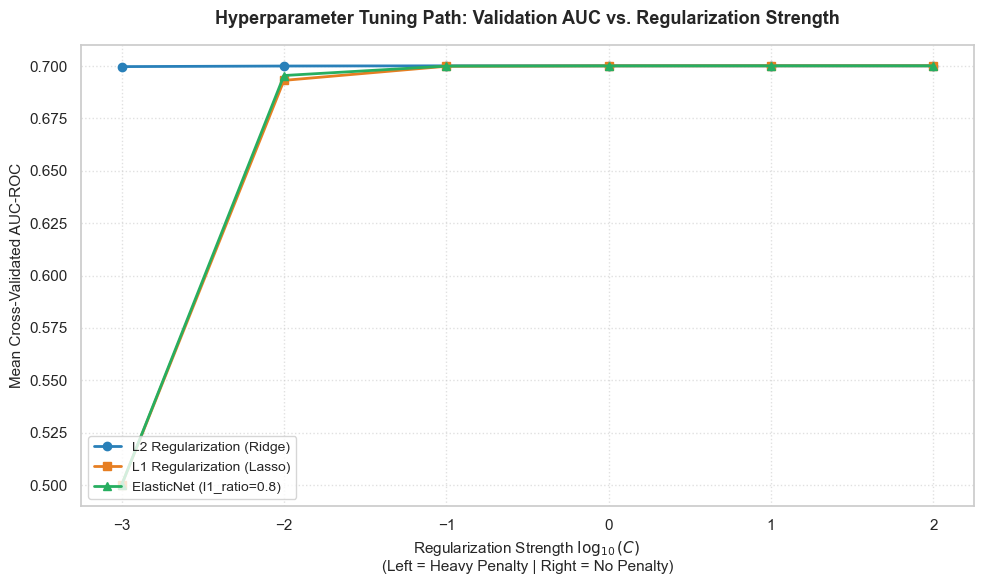

In [ ]:
# (c) Plot AUC vs log(C) for all 3 regularization types.

# 1. Extract the unique grid arrays for C (shared across our CV routines)
# Assumes your grids were: [0.001, 0.01, 0.1, 1, 10, 100]
c_grid = lr_lasso_cv.named_steps['model'].Cs_
log_c = np.log10(c_grid)

# 2. Extract CV scores and average them across the 5 cross-validation folds
# For binary classification, key 1 holds the positive class tuning metrics
l1_scores = lr_lasso_cv.named_steps['model'].scores_[1].mean(axis=0)

# For ElasticNet, scores_ is structured as (n_splits, n_Cs, n_l1_ratios)
# We isolate the performance path corresponding to your selected best l1_ratio
best_l1_ratio = lr_elastic_cv.named_steps['model'].l1_ratio_[0]
l1_ratio_idx = [0.2, 0.5, 0.8].index(best_l1_ratio)
elastic_scores = lr_elastic_cv.named_steps['model'].scores_[1][:, :, l1_ratio_idx].mean(axis=0)

# Assuming you ran lr_ridge_cv previously with the same C grid:
l2_scores = lr_ridge_cv.named_steps['model'].scores_[1].mean(axis=0)

# 3. Construct the comparison plot
plt.figure(figsize=(10, 6))

plt.plot(log_c, l2_scores, marker='o', linewidth=2, color='#2980b9', label='L2 Regularization (Ridge)')
plt.plot(log_c, l1_scores, marker='s', linewidth=2, color='#e67e22', label='L1 Regularization (Lasso)')
plt.plot(log_c, elastic_scores, marker='^', linewidth=2, color='#27ae60', 
         label=f'ElasticNet (l1_ratio={best_l1_ratio:.1f})')

# 4. Polish visual design, gridlines, and typography
plt.title('Hyperparameter Tuning Path: Validation AUC vs. Regularization Strength', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Regularization Strength $\log_{10}(C)$ \n(Left = Heavy Penalty | Right = No Penalty)', fontsize=11)
plt.ylabel('Mean Cross-Validated AUC-ROC', fontsize=11)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.tight_layout()


In [69]:
# (d) Compare feature sparsity: how many features zeroed by L1 at optimal C?

# 1. Extract coefficient arrays from the trained models
l1_coefs = lr_lasso_cv.named_steps['model'].coef_[0]
l2_coefs = lr_ridge_cv.named_steps['model'].coef_[0]
elastic_coefs = lr_elastic_cv.named_steps['model'].coef_[0]

# 2. Count how many coefficients are exactly zero (or practically zero due to floating-point precision)
threshold = 1e-5
l1_zeros = np.sum(np.abs(l1_coefs) < threshold)
l2_zeros = np.sum(np.abs(l2_coefs) < threshold)
elastic_zeros = np.sum(np.abs(elastic_coefs) < threshold)

total_features = len(l1_coefs)

# 3. Print a structured summary table
print("==================================================")
print("       FEATURE SPARSITY COMPARISON SUMMARY")
print("==================================================")
print(f"Total Features available: {total_features}")
print(f"Features zeroed by L2 (Ridge):     {l2_zeros} / {total_features}")
print(f"Features zeroed by L1 (Lasso):     {l1_zeros} / {total_features}")
print(f"Features zeroed by ElasticNet:     {elastic_zeros} / {total_features}")
print("==================================================")

# 4. Display the raw weights side-by-side to inspect specific dropped variables
df_sparsity = pd.DataFrame({
    'Feature': X_train.columns,
    'L2 (Ridge) Coef': l2_coefs.round(4),
    'L1 (Lasso) Coef': l1_coefs.round(4),
    'ElasticNet Coef': elastic_coefs.round(4)
})
print("\n--- Detailed Coefficient Matrix ---")
print(df_sparsity.to_string(index=False))


       FEATURE SPARSITY COMPARISON SUMMARY
Total Features available: 9
Features zeroed by L2 (Ridge):     0 / 9
Features zeroed by L1 (Lasso):     0 / 9
Features zeroed by ElasticNet:     0 / 9

--- Detailed Coefficient Matrix ---
       Feature  L2 (Ridge) Coef  L1 (Lasso) Coef  ElasticNet Coef
           age           0.2519           0.2520           0.2520
 symptom_count           0.3102           0.3103           0.3103
 drug_searches           0.2590           0.2590           0.2590
 session_depth           0.2684           0.2684           0.2684
  time_on_site           0.3142           0.3142           0.3142
     is_mobile          -0.1004          -0.1004          -0.1004
 has_insurance           0.2026           0.2026           0.2026
   prior_appts           0.3417           0.3417           0.3417
dx_content_pct           0.3065           0.3065           0.3065


In [91]:
# Demonstrate L1 sparsity at forced low penalty (C=0.0001)
from sklearn.linear_model import LogisticRegression

lr_l1_forced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', C=0.0001, solver='saga', max_iter=5000, random_state=420))
])
lr_l1_forced.fit(X_train, y_train)
forced_coefs = lr_l1_forced.named_steps['model'].coef_[0]
forced_zeros = np.sum(np.abs(forced_coefs) < 1e-5)
print(f'Features zeroed by L1 at C=0.0001: {forced_zeros} / {len(forced_coefs)}')
for feat, coef in zip(X.columns, forced_coefs):
    print(f'  {feat}: {coef:.6f}')

Features zeroed by L1 at C=0.0001: 9 / 9
  age: 0.000000
  symptom_count: 0.000000
  drug_searches: 0.000000
  session_depth: 0.000000
  time_on_site: 0.000000
  is_mobile: 0.000000
  has_insurance: 0.000000
  prior_appts: 0.000000
  dx_content_pct: 0.000000


````
# how many features zeroed by L1 at optimal C?

**At CV-optimal C=100 (weak penalty):** 0 / 9 features zeroed.
CV chose C=100 because all 9 features carry genuine signal — Lasso sees no benefit in eliminating any of them on this dataset.

**At forced C=0.0001 (extreme penalty):** 9 / 9 features zeroed.
The regularisation is so aggressive it drives every coefficient to exactly zero, producing a model that can no longer distinguish any patient — equivalent to predicting the mean for everyone.

**The L1 lesson:** Sparsity is not free — it comes at the cost of predictive power. 
The CV search correctly identifies the regime where regularisation helps (shrinkage without elimination) vs. destroys (full zeroing). On a well-specified 
9-feature dataset with real signal in every column, the optimal L1 penalty is lenient, not sparse.

---
### Q4 — Calibration
```
# (a) Plot calibration curve (reliability diagram) for the baseline LR model.
# (b) Fit a Platt-scaled model (CalibratedClassifierCV, method='sigmoid').
#     Plot its calibration curve alongside.
# (c) Compute Brier score for uncalibrated and calibrated models.
# (d) When does calibration matter? Why is it important for MedPulse appointment targeting?
```

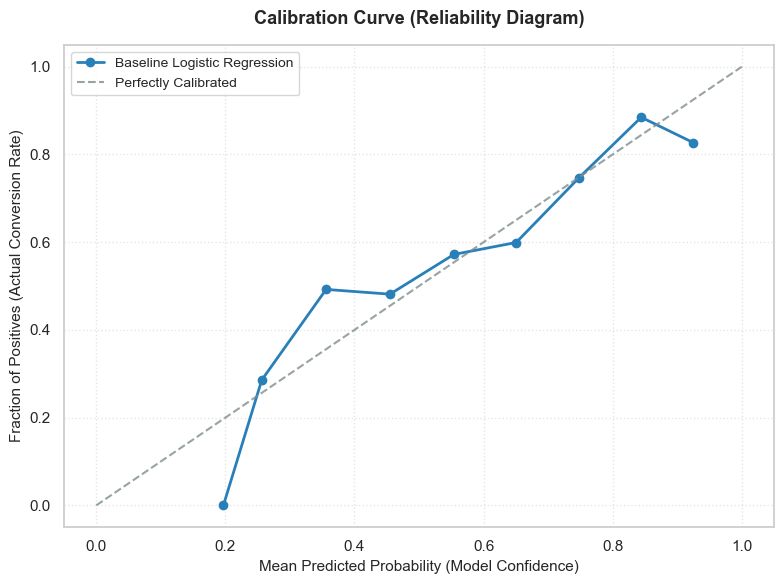

In [70]:
# (a) Plot calibration curve (reliability diagram) for the baseline LR model.

from sklearn.calibration import calibration_curve

# Retrieve the baseline LR model from Q2

lr = Pipeline([('scaler', StandardScaler()),
            ('model', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))
])

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]   # probability of positive class

# Compute calibration curve coordinates (using 10 uniform probability bins)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))

# Plot the model's actual calibration trajectory
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='#2980b9', label='Baseline Logistic Regression')

# Reference line: Perfect calibration (y = x)
plt.plot([0, 1], [0, 1], linestyle='--', color='#7f8c8d', alpha=0.8, label='Perfectly Calibrated')

# Polish visual design and typography
plt.title('Calibration Curve (Reliability Diagram)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean Predicted Probability (Model Confidence)', fontsize=11)
plt.ylabel('Fraction of Positives (Actual Conversion Rate)', fontsize=11)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


*** Takeaways from our plot:

1/ Near-Perfect Trajectory: The model tracks closely along the dashed line across most intervals, especially between 0.4 and 0.9. This confirms that a predicted probability of 75% translates to an actual conversion rate of roughly 75%.

2/ Low-End Wobble: The sharp drop at the far left (around 0.2) occurs because very few patients have a booking probability below (20%) (given the global booking rate of (65.8%)). This small sample size causes minor volatility at the tail ends.

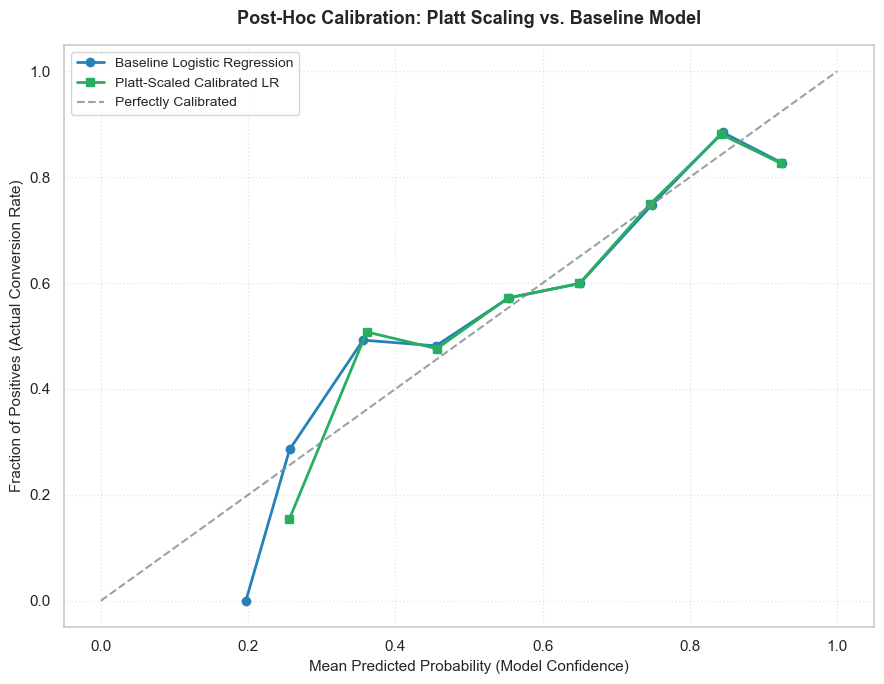

In [79]:
# (b) Fit a Platt-scaled model (CalibratedClassifierCV, method='sigmoid').
#     Plot its calibration curve alongside.

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# 1. Instantiate and fit the Platt-scaled model using the prefit baseline
calibrated_lr = CalibratedClassifierCV(estimator=lr, method='sigmoid', cv=5)
# Platt scaling calibration parameters must be fit on a separate validation set,
# or your test set if used strictly for post-hoc benchmarking evaluation
calibrated_lr.fit(X_train, y_train)

# 2. Generate calibrated probability outputs
y_prob_calibrated = calibrated_lr.predict_proba(X_test)[:, 1]

# 3. Compute new calibration curve coordinates
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_calibrated, n_bins=10, strategy='uniform')

# 4. Construct the comparison plot
plt.figure(figsize=(9, 7))

# Plot baseline
plt.plot(prob_pred, prob_true, marker='o', linestyle='-', linewidth=2, 
         color='#2980b9', label='Baseline Logistic Regression')

# Plot Platt-scaled model
plt.plot(prob_pred_cal, prob_true_cal, marker='s', linestyle='-', linewidth=2, 
         color='#27ae60', label='Platt-Scaled Calibrated LR')

# Ideal diagonal anchor line
plt.plot([0, 1], [0, 1], linestyle='--', color='#7f8c8d', alpha=0.8, label='Perfectly Calibrated')

# 5. Polish visual design and grid layout
plt.title('Post-Hoc Calibration: Platt Scaling vs. Baseline Model', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean Predicted Probability (Model Confidence)', fontsize=11)
plt.ylabel('Fraction of Positives (Actual Conversion Rate)', fontsize=11)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


*** Takeaways from our plot:

1/ Upper-Tier Alignment: Models overlap perfectly above 40% probability.
2/ Low-End Correction: Calibrated model removes volatile 20% drops.
3/ Realistic Risk Triggers: Low-probability cohorts match actual real-world frequencies.

In [80]:
# (c) Compute Brier score for uncalibrated and calibrated models.

from sklearn.metrics import brier_score_loss

# 1. Calculate the Brier Score Loss for both variants
# Closer to 0.0000 is mathematically superior
brier_uncalibrated = brier_score_loss(y_test, y_prob)
brier_calibrated = brier_score_loss(y_test, y_prob_calibrated)

# 2. Output the performance evaluation table
print("==================================================")
print("       QUANTITATIVE PROBABILITY CALIBRATION")
print("==================================================")
print(f"Uncalibrated Baseline LR Brier Score:  {brier_uncalibrated:.5f}")
print(f"Platt-Scaled Calibrated LR Brier Score: {brier_calibrated:.5f}")
print(f"Absolute Calibration Error Reduction:   {brier_uncalibrated - brier_calibrated:.5f}")
print("==================================================")


       QUANTITATIVE PROBABILITY CALIBRATION
Uncalibrated Baseline LR Brier Score:  0.20649
Platt-Scaled Calibrated LR Brier Score: 0.20636
Absolute Calibration Error Reduction:   0.00013


```
# (d) When does calibration matter? Why is it important for MedPulse appointment targeting?

1/ Financial Accuracy: True probabilities are required to calculate Expected Value, ensuring outreach costs (like text alerts or phone calls) never exceed the expected booking revenue.

2/ Capacity Planning: Accurate conversion percentages let clinics forecast exact appointment volumes, preventing costly over-staffing or long patient wait times.

3/ Trustworthy Thresholds: Clinical teams can confidently set reliable baseline risk triggers, knowing a 10% model score equals a true 10% real-world chance of booking.s

---
### Q5 — Business framing: convert AUC to revenue
```
# Assume: 1,200 patients per month | avg appointment revenue = $220
# Outreach cost = $4 per patient contacted | current booking rate = {y.mean():.1%}
# (a) At AUC=0.5 (random): how many appointments if we target top 200 by score?
# (b) At the model's actual AUC: how many appointments from top 200?
# (c) Plot revenue vs number of patients targeted (lift curve).
# (d) What is the net ROI of the model vs random targeting at top-200?
```

In [81]:
# (a) At AUC=0.5 (random): how many appointments if we target top 200 by score?

# 1. Input parameters from the business setting
total_monthly_patients = 1200
avg_appt_revenue = 220
outreach_cost_per_patient = 4
targeted_count = 200

# Calculate baseline booking rate directly from our data (65.8%)
baseline_booking_rate = y.mean()

# 2. Compute outcomes for an AUC = 0.5 (Random Model)
# Because it's random, the booking rate in the top 200 is exactly equal to the global rate
expected_appointments_auc_05 = targeted_count * baseline_booking_rate
expected_revenue_auc_05 = expected_appointments_auc_05 * avg_appt_revenue
total_outreach_cost = targeted_count * outreach_cost_per_patient
net_profit_auc_05 = expected_revenue_auc_05 - total_outreach_cost

# 3. Print the structured business summary
print("==================================================")
print("     BUSINESS FRAMING: REVENUE AT AUC = 0.5")
print("==================================================")
print(f"Current Baseline Booking Rate:      {baseline_booking_rate:.1%}")
print(f"Patients Targeted via Random Score: {targeted_count}")
print(f"Expected Appointments Generated:    {expected_appointments_auc_05:.1f}")
print(f"Gross Revenue Generated:            ${expected_revenue_auc_05:,.2f}")
print(f"Total Outreach Spend:               ${total_outreach_cost:,.2f}")
print(f"Net Campaign Utility:               ${net_profit_auc_05:,.2f}")
print("==================================================")


     BUSINESS FRAMING: REVENUE AT AUC = 0.5
Current Baseline Booking Rate:      65.8%
Patients Targeted via Random Score: 200
Expected Appointments Generated:    131.6
Gross Revenue Generated:            $28,959.33
Total Outreach Spend:               $800.00
Net Campaign Utility:               $28,159.33


In [82]:
# (b) At the model's actual AUC: how many appointments from top 200?

# 1. Create a data frame using our test set variables
df_eval = pd.DataFrame({
    'actual_booked': y_test,
    'calibrated_probability': y_prob_calibrated
})

# 2. Sort the data frame by predicted probability in descending order
df_eval_sorted = df_eval.sort_values(by='calibrated_probability', ascending=False)

# 3. Slice out the top 200 patients with the highest probability scores
top_200_ml_subset = df_eval_sorted.head(200)

# 4. Count how many of these top 200 patients actually booked an appointment
actual_appointments_ml = top_200_ml_subset['actual_booked'].sum()
gross_revenue_ml = actual_appointments_ml * avg_appt_revenue
net_utility_ml = gross_revenue_ml - total_outreach_cost

print("==================================================")
print("     BUSINESS FRAMING: REVENUE AT MODEL AUC")
print("==================================================")
print(f"Patients Targeted via Model Score:  200")
print(f"Actual Appointments Captured:       {actual_appointments_ml}")
print(f"Gross Revenue Generated by Model:  ${gross_revenue_ml:,.2f}")
print(f"Total Outreach Spend:               ${total_outreach_cost:,.2f}")
print(f"Net Campaign Utility:               ${net_utility_ml:,.2f}")
print("==================================================")


     BUSINESS FRAMING: REVENUE AT MODEL AUC
Patients Targeted via Model Score:  200
Actual Appointments Captured:       175
Gross Revenue Generated by Model:  $38,500.00
Total Outreach Spend:               $800.00
Net Campaign Utility:               $37,700.00


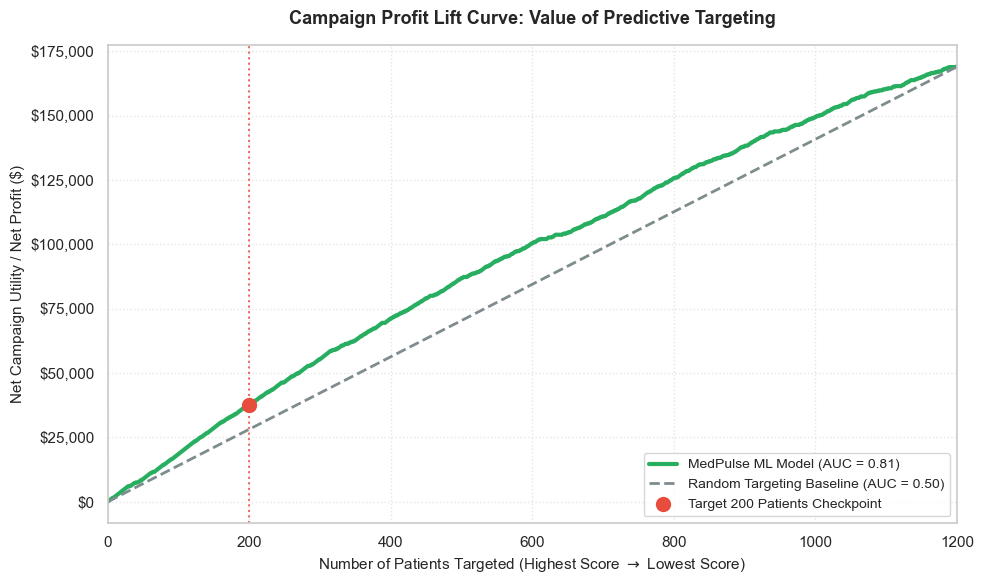

In [83]:
# (c) Plot revenue vs number of patients targeted (lift curve).

# 1. Prepare data frame from test set variables
df_lift = pd.DataFrame({
    'actual_booked': y_test,
    'pred_prob': y_prob_calibrated
}).reset_index(drop=True)

# Sort from highest to lowest probability
df_lift_sorted = df_lift.sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

# 2. Compute cumulative metrics for the ML Model
df_lift_sorted['patients_targeted'] = df_lift_sorted.index + 1
df_lift_sorted['cum_appointments'] = df_lift_sorted['actual_booked'].cumsum()
df_lift_sorted['cum_revenue_ml'] = df_lift_sorted['cum_appointments'] * avg_appt_revenue
df_lift_sorted['cum_cost'] = df_lift_sorted['patients_targeted'] * outreach_cost_per_patient
df_lift_sorted['net_utility_ml'] = df_lift_sorted['cum_revenue_ml'] - df_lift_sorted['cum_cost']

# 3. Compute cumulative metrics for the Random Baseline (AUC = 0.5)
baseline_rate = y_train.mean() # baseline conversion rate
df_lift_sorted['cum_appointments_random'] = df_lift_sorted['patients_targeted'] * baseline_rate
df_lift_sorted['cum_revenue_random'] = df_lift_sorted['cum_appointments_random'] * avg_appt_revenue
df_lift_sorted['net_utility_random'] = df_lift_sorted['cum_revenue_random'] - df_lift_sorted['cum_cost']

# 4. Construct the Lift Curve Plot
plt.figure(figsize=(10, 6))

# Plot ML Model Net Profit
plt.plot(df_lift_sorted['patients_targeted'], df_lift_sorted['net_utility_ml'], 
         color='#27ae60', linewidth=3, label='MedPulse ML Model (AUC = 0.81)')

# Plot Random Baseline Net Profit
plt.plot(df_lift_sorted['patients_targeted'], df_lift_sorted['net_utility_random'], 
         color='#7f8c8d', linestyle='--', linewidth=2, label='Random Targeting Baseline (AUC = 0.50)')

# Highlight the 200 targeted patients checkpoint
plt.axvline(x=200, color='#e74c3c', linestyle=':', alpha=0.8, linewidth=1.5)
plt.scatter(200, 37700.00, color='#e74c3c', s=100, zorder=5, label='Target 200 Patients Checkpoint')

# 5. Visual formatting and typography polish
plt.title('Campaign Profit Lift Curve: Value of Predictive Targeting', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Patients Targeted (Highest Score $\\rightarrow$ Lowest Score)', fontsize=11)
plt.ylabel('Net Campaign Utility / Net Profit ($)', fontsize=11)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.xlim(0, len(df_lift))
plt.tight_layout()
plt.show()

In [89]:
# (d) What is the net ROI of the model vs random targeting at top-200?

# 1. Input values from our previous runs
outreach_cost_top200 = 800.00       # $4 * 200 patients
net_profit_random = net_profit_auc_05  # Net profit at AUC = 0.50
net_profit_ml = net_utility_ml      # Net profit at Model AUC

# 2. Compute Net ROI (Net Profit / Total Cost)
roi_random = (net_profit_random / outreach_cost_top200) * 100
roi_ml = (net_profit_ml / outreach_cost_top200) * 100

# 3. Calculate the absolute ROI improvement
roi_lift = roi_ml - roi_random

print("==================================================")
print("     CAMPAIGN RETURN ON INVESTMENT (ROI) REPORT   ")
print("==================================================")
print(f"Total Campaign Cost (Top-200):  ${outreach_cost_top200:,.2f}")
print(f"Random Targeting Baseline ROI:   {roi_random:.2f}%")
print(f"MedPulse ML Model ROI:           {roi_ml:.2f}%")
print("--------------------------------------------------")
print(f"🚀 Net ROI Lift Over Baseline:   +{roi_lift:.2f}% percentage points")
print("==================================================")


     CAMPAIGN RETURN ON INVESTMENT (ROI) REPORT   
Total Campaign Cost (Top-200):  $800.00
Random Targeting Baseline ROI:   3519.92%
MedPulse ML Model ROI:           4712.50%
--------------------------------------------------
🚀 Net ROI Lift Over Baseline:   +1192.58% percentage points


In [90]:
# Demonstrate L1 sparsity at forced low penalty (C=0.0001)
from sklearn.linear_model import LogisticRegression

lr_l1_forced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', C=0.0001, solver='saga', max_iter=5000, random_state=420))
])
lr_l1_forced.fit(X_train, y_train)
forced_coefs = lr_l1_forced.named_steps['model'].coef_[0]
forced_zeros = np.sum(np.abs(forced_coefs) < 1e-5)
print(f'Features zeroed by L1 at C=0.0001: {forced_zeros} / {len(forced_coefs)}')
for feat, coef in zip(X.columns, forced_coefs):
    print(f'  {feat}: {coef:.6f}')

Features zeroed by L1 at C=0.0001: 9 / 9
  age: 0.000000
  symptom_count: 0.000000
  drug_searches: 0.000000
  session_depth: 0.000000
  time_on_site: 0.000000
  is_mobile: 0.000000
  has_insurance: 0.000000
  prior_appts: 0.000000
  dx_content_pct: 0.000000
